# Expected metrics for evaluating football team performance

This notebook is the computational source for the expected-goals part
of the thesis application. It does **not** estimate a new expected-goals
model. Instead, it analyses expected metrics already supplied by
Understat (`xG`, `xGA`, and `xPts`) and compares them with observed
goals, goals conceded, and points.

The analysis has four goals:

1. compare scoring environments across the top five European leagues;
2. describe the development of `xG` and actual goals through time;
3. identify persistent performance above or below expectation;
4. use Leicester City's 2015/16 title season as a case study, including
   exploratory team-profile clustering.

All transformations, parameter choices, sign conventions, validation
checks, and exports used by the Czech thesis-output notebook are kept
here so that the workflow can be reproduced from the raw CSV files.

## 1. Setup and metric conventions

Understat's original difference columns use the following directions:

$$
xG_{\mathrm{diff}} = xG - G,\qquad
xPts_{\mathrm{diff}} = xPts - P.
$$

A negative value in either original column therefore means that the
team exceeded the corresponding expectation. To avoid reversing this
interpretation, the notebook creates `goals_minus_xg` and
`points_minus_xpts`. In both variables, a positive value means
performance above expectation. For defence,
`xga_minus_conceded = xGA - goals conceded`, so a positive value means
fewer goals conceded than expected.

In [1]:
from pathlib import Path
import json
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    candidate = PROJECT_ROOT.parent
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
    else:
        raise FileNotFoundError("Run the notebook from the xG project directory.")

CACHE_DIR = PROJECT_ROOT / ".cache" / "thesis_cs"
MPLCONFIG_DIR = PROJECT_ROOT / ".cache" / "matplotlib"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_DIR))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.clustering import (
    get_cluster_members,
    get_dbscan_k_distance_table,
    plot_cluster_scatter,
    plot_dendrogram,
    relabel_clusters_by_anchors,
    run_dbscan,
    run_hierarchical_clustering,
    summarize_clusters,
    summarize_dbscan_sensitivity,
)
from src.config import configure_pandas, configure_plots
from src.data_prep import (
    get_dataset_overview,
    get_missing_values_table,
    load_dataset,
)
from src.metrics import (
    add_expected_performance_differences,
    aggregate_rolling_match_series,
    compute_team_ratios,
    filter_league_season,
    get_league_per_match_summary,
    get_season_completeness_summary,
    get_top_defensive_teams,
    get_top_offensive_teams,
    reconstruct_physical_matches,
    teams_present_in_all_seasons,
)
from src.plotting import (
    plot_identity_scatter,
    plot_rolling_time_series,
)

configure_pandas()
configure_plots()
np.random.seed(42)

MATCH_ROLLING_WINDOW_TOP5 = 490
MATCH_ROLLING_WINDOW_LA_LIGA = 100
SELECTED_TIME_SERIES_LEAGUE = "La Liga"
DBSCAN_EPS = 0.73
DBSCAN_MIN_SAMPLES = 3
N_HIERARCHICAL_CLUSTERS = 4

## 2. Data and analytical sample

Two levels of aggregation are required:

- `understat.csv` contains one row per team and season. It is used for
  long-term ratios, the Leicester case study, and clustering.
- `understat_per_game.csv` contains one row per team and match. It is
  used for league-level per-match comparisons and moving averages.

The sample is restricted to the Bundesliga, Premier League, La Liga,
Ligue 1, and Serie A from 2014/15 to 2019/20. Each match contributes two
team-match observations, one for each participating team.

In [2]:
season_data = add_expected_performance_differences(
    load_dataset(PROJECT_ROOT / "data" / "understat.csv", top5_only=True)
)
match_data = load_dataset(
    PROJECT_ROOT / "data" / "understat_per_game.csv",
    top5_only=True,
)

overview = pd.DataFrame(
    {
        "team-season data": get_dataset_overview(season_data),
        "team-match data": get_dataset_overview(match_data),
    }
)
display(overview.loc[["shape", "n_duplicates", "n_leagues", "n_seasons", "n_teams"]])

,team-season data,team-match data
shape,"(588, 27)","(21700, 29)"
n_duplicates,0,0
n_leagues,5,5
n_seasons,6,6
n_teams,143,143


The data-quality checks below are intentionally executable. They catch
duplicate records, invalid dates, missing values in the analytical
variables, and changes in the sign convention of Understat's original
difference columns before any results are produced.

In [3]:
required_season_columns = [
    "league", "season_year", "position", "team", "matches",
    "scored", "missed", "pts", "xg", "xga", "xpts",
    "ppda_coef", "oppda_coef", "deep",
    "goals_minus_xg", "points_minus_xpts", "xga_minus_conceded",
]
required_match_columns = [
    "league", "season_year", "team", "date", "xg", "scored",
]

assert not season_data.duplicated().any()
assert not match_data.duplicated().any()
assert match_data["date"].notna().all()
assert season_data[required_season_columns].notna().all().all()
assert match_data[required_match_columns].notna().all().all()
assert np.allclose(season_data["xg_diff"], -season_data["goals_minus_xg"])
assert np.allclose(season_data["xpts_diff"], -season_data["points_minus_xpts"])

missing_values = get_missing_values_table(
    season_data[required_season_columns]
)
display(missing_values.loc[missing_values["missing_count"].gt(0)])
print("All analytical validation checks passed.")

,missing_count,missing_pct


All analytical validation checks passed.


### 2.1 Season completeness

Schedule length differs across competitions: Bundesliga clubs normally
play 34 matches, whereas clubs in the other four leagues normally play
38. The local data also contain two incomplete league-seasons in
2019/20. Ligue 1 covers only 27–28 matches per team and Serie A covers
37–38. This is stated explicitly rather than treating the final season
as uniformly complete.

In [4]:
completeness = get_season_completeness_summary(match_data)
incomplete_seasons = completeness.loc[
    ~completeness["full_schedule_coverage"],
    [
        "league", "season", "n_teams", "min_matches", "max_matches",
        "expected_matches_per_team", "coverage",
    ],
].copy()
incomplete_seasons["coverage_pct"] = 100 * incomplete_seasons["coverage"]

display(
    incomplete_seasons[
        [
            "league", "season", "n_teams", "min_matches", "max_matches",
            "expected_matches_per_team", "coverage_pct",
        ]
    ].round({"coverage_pct": 1})
)

assert len(incomplete_seasons) == 2
assert set(incomplete_seasons["league"]) == {"Ligue 1", "Serie A"}

,league,season,n_teams,min_matches,max_matches,expected_matches_per_team,coverage_pct
28,Ligue 1,2019/20,20,27,28,38,73.40
29,Serie A,2019/20,20,37,38,38,98.70


## 3. Comparison of leagues on a per-match basis

Raw team-season totals are not comparable when leagues differ in both
the number of clubs and matches. The next table therefore reports
expected goals and actual goals **per team and match**:

$$
\overline{xG}_{l} =
\frac{\sum_{i\in l} xG_i}{N_l},
\qquad
\overline{G}_{l} =
\frac{\sum_{i\in l} G_i}{N_l},
$$

where $N_l$ is the number of team-match observations in league
$l$ over the observed seasons.

In [5]:
league_per_match = get_league_per_match_summary(match_data)
league_table = league_per_match[
    [
        "league", "teams_per_season_min", "teams_per_season_max",
        "n_team_seasons", "team_matches",
        "avg_xg_per_team_match", "avg_goals_per_team_match",
    ]
].copy()
display(
    league_table.round(
        {
            "avg_xg_per_team_match": 3,
            "avg_goals_per_team_match": 3,
        }
    )
)

,league,teams_per_season_min,teams_per_season_max,n_team_seasons,team_matches,avg_xg_per_team_match,avg_goals_per_team_match
0,Bundesliga,18,18,108,3672,1.43,1.47
1,Serie A,20,20,120,4550,1.35,1.38
2,EPL,20,20,120,4560,1.34,1.36
3,La Liga,20,20,120,4560,1.33,1.34
4,Ligue 1,20,20,120,4358,1.24,1.29


The Bundesliga has the highest average values in the sample
(1.432 $xG$ and 1.469 goals per team-match), while Ligue 1 has the
lowest (1.243 $xG$ and 1.287 goals). Actual goals are slightly above
$xG$ in every league, but the gaps are small relative to the overall
scoring level.
The ranking is descriptive and should not be read as a causal
comparison of league quality.

## 4. Development of $xG$ and goals over time

Match-level observations are used to study how $xG$ and actual goals
develop over time. Each match enters the sequence once. For match $r$,
the values retain the per-team-and-match scale:

$$
z_r=\frac{z_{r,\mathrm{home}}+z_{r,\mathrm{away}}}{2},
\qquad z\in\{xG,G\}.
$$

Fixtures are ordered by kick-off time and the trailing moving average
is calculated directly over this sequence:

$$
MA_t^{(w)}(z)=\frac{1}{w}\sum_{j=0}^{w-1}z_{t-j}.
$$

The common top-five series uses $w=490$: ten full sets of fixtures
across the five leagues, each containing
$10+10+10+10+9=49$ matches. The La Liga series uses $w=100$, which
equals ten sets of ten fixtures. The window is not reset at season
boundaries and no monthly aggregation is applied. Simultaneous
kick-offs are ordered deterministically by league and team names.
Only complete league-seasons are included.

In [6]:
complete_league_seasons = completeness.loc[
    completeness["full_schedule_coverage"],
    ["league", "season_year"],
]
complete_match_data = match_data.merge(
    complete_league_seasons,
    on=["league", "season_year"],
    how="inner",
    validate="many_to_one",
)

physical_matches = reconstruct_physical_matches(complete_match_data)
assert len(physical_matches) * 2 == len(complete_match_data)
assert np.isclose(
    physical_matches["xg_per_team"].mean(),
    complete_match_data["xg"].mean(),
)
assert np.isclose(
    physical_matches["goals_per_team"].mean(),
    complete_match_data["scored"].mean(),
)

complete_league_counts = (
    completeness.loc[completeness["full_schedule_coverage"]]
    .groupby("season_year")["league"]
    .nunique()
)
common_complete_years = complete_league_counts.loc[
    complete_league_counts.eq(5)
].index
assert common_complete_years.tolist() == [
    2014, 2015, 2016, 2017, 2018
]

top5_matches = physical_matches.loc[
    physical_matches["season_year"].isin(common_complete_years)
].copy()
la_liga_matches = physical_matches.loc[
    physical_matches["league"].eq(SELECTED_TIME_SERIES_LEAGUE)
].copy()

rolling_match_top5_ma490 = aggregate_rolling_match_series(
    top5_matches,
    window=MATCH_ROLLING_WINDOW_TOP5,
)
rolling_match_la_liga_ma100 = aggregate_rolling_match_series(
    la_liga_matches,
    window=MATCH_ROLLING_WINDOW_LA_LIGA,
)

assert len(rolling_match_top5_ma490) == (
    len(top5_matches) - MATCH_ROLLING_WINDOW_TOP5 + 1
)
assert len(rolling_match_la_liga_ma100) == (
    len(la_liga_matches)
    - MATCH_ROLLING_WINDOW_LA_LIGA
    + 1
)

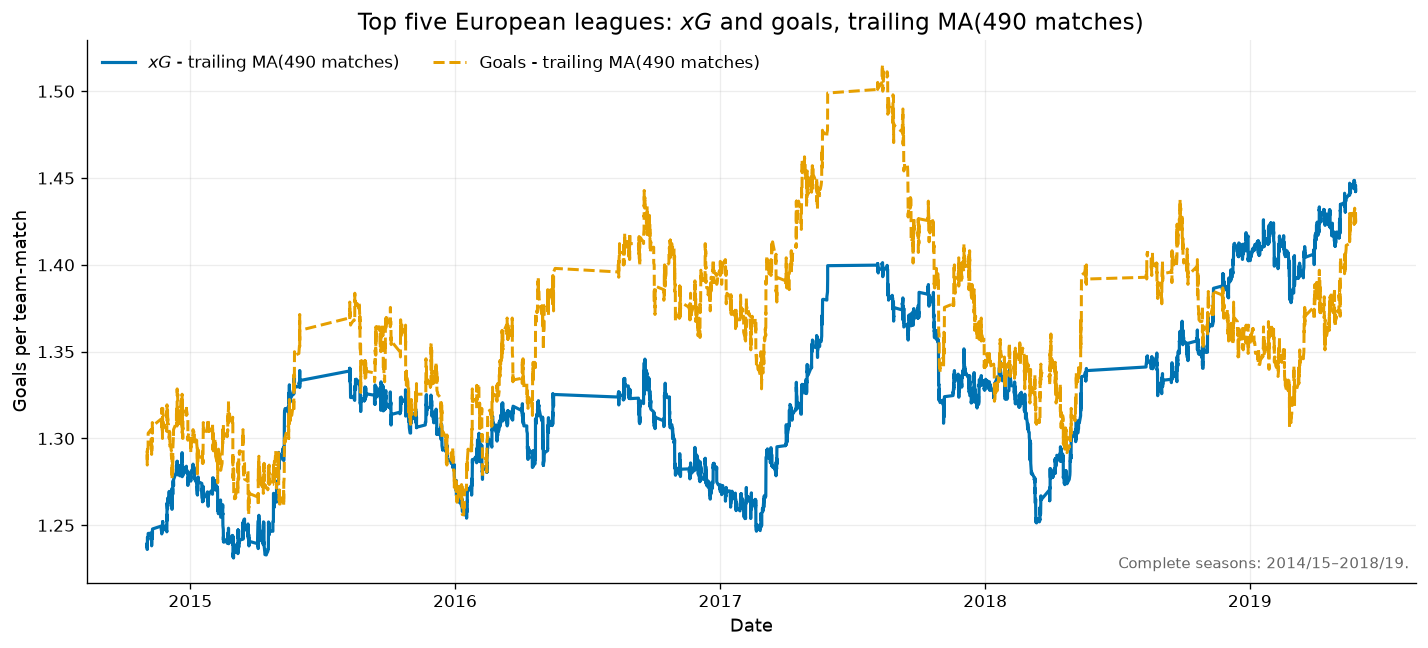

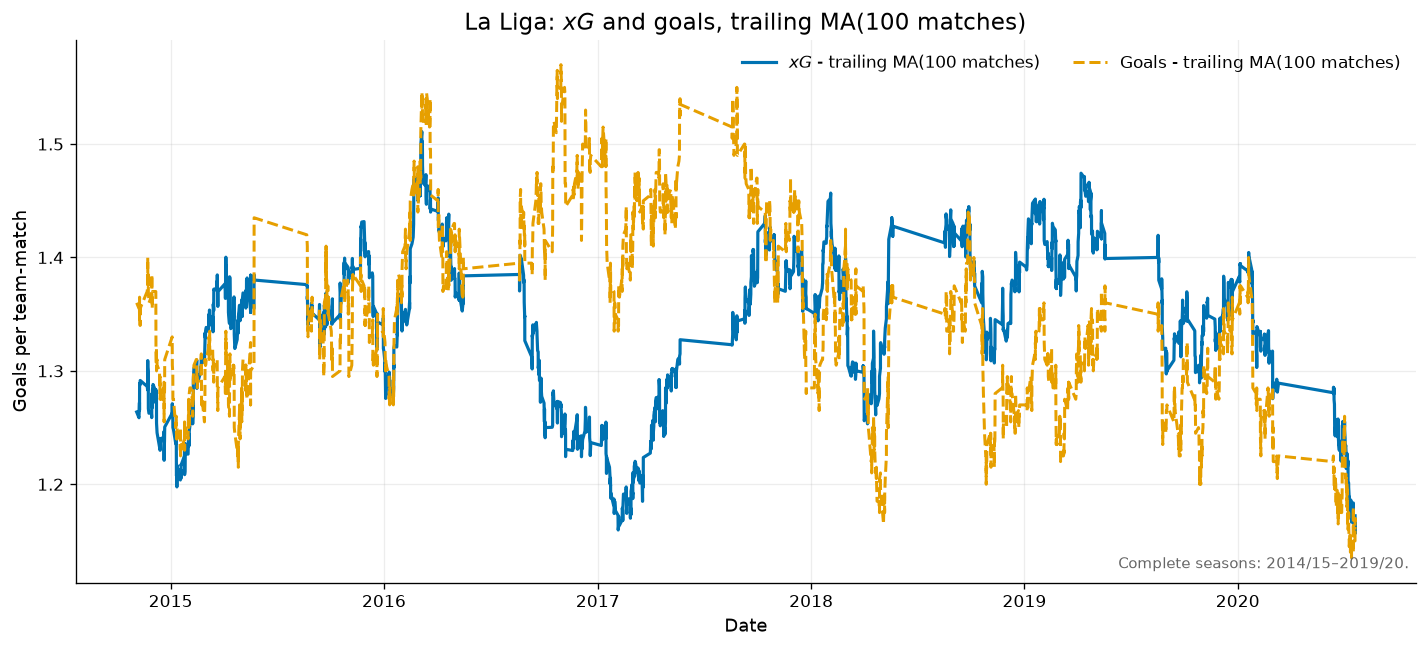

In [7]:
fig, ax = plot_rolling_time_series(
    rolling_match_top5_ma490,
    title=(
        "Top five European leagues: $xG$ and goals, "
        "trailing MA(490 matches)"
    ),
    xg_label="$xG$ - trailing MA(490 matches)",
    goals_label="Goals - trailing MA(490 matches)",
    annotation="Complete seasons: 2014/15–2018/19.",
)
plt.show()

fig, ax = plot_rolling_time_series(
    rolling_match_la_liga_ma100,
    title="La Liga: $xG$ and goals, trailing MA(100 matches)",
    xg_label="$xG$ - trailing MA(100 matches)",
    goals_label="Goals - trailing MA(100 matches)",
    annotation="Complete seasons: 2014/15–2019/20.",
)
plt.show()

## 5. Long-term performance above and below expectation

To reduce the influence of single-season variation, this comparison
keeps only clubs present in every one of the six observed seasons of
their league. There are 59 such clubs, not 69.

Offensive and defensive ratios are defined as

$$
R_{\mathrm{off}}=
\frac{\sum G}{\sum xG},
\qquad
R_{\mathrm{def}}=
\frac{\sum GA}{\sum xGA}.
$$

Values of $R_{\mathrm{off}}>1$ indicate more goals scored than
expected. For defence, lower values are better:
$R_{\mathrm{def}}<1$ means fewer goals conceded than expected.
These are descriptive multi-season ratios and do not isolate finishing,
goalkeeping, tactics, or data-provider model effects.

In [8]:
stable_team_seasons = teams_present_in_all_seasons(season_data)
stable_team_count = (
    stable_team_seasons[["league", "team"]].drop_duplicates().shape[0]
)
assert stable_team_count == 59

team_ratios = compute_team_ratios(stable_team_seasons)
top_offensive = get_top_offensive_teams(team_ratios, n=5)
top_defensive = get_top_defensive_teams(team_ratios, n=5)

print(f"Teams present in all six seasons: {stable_team_count}")
display(
    top_offensive[
        ["league", "team", "xg", "goals_scored", "offensive_ratio"]
    ].round(3)
)
display(
    top_defensive[
        ["league", "team", "xga", "goals_conceded", "defensive_ratio"]
    ].round(3)
)

Teams present in all six seasons: 59


,league,team,xg,goals_scored,offensive_ratio
0,Serie A,Juventus,388.33,456,1.17
1,Bundesliga,Werder Bremen,261.40,298,1.14
2,EPL,Tottenham,365.55,415,1.14
3,Ligue 1,Lyon,371.22,418,1.13
4,La Liga,Real Sociedad,282.27,315,1.12


,league,team,xga,goals_conceded,defensive_ratio
0,La Liga,Atletico Madrid,196.63,152,0.77
1,La Liga,Barcelona,218.16,190,0.87
2,EPL,Tottenham,267.04,236,0.88
3,EPL,Manchester United,245.02,219,0.89
4,Ligue 1,Nice,284.92,255,0.90


Juventus records the highest long-term offensive ratio (1.174), while
Atlético Madrid records the lowest defensive ratio (0.773). Tottenham
appears in both top-five lists. The direction of the defensive ranking
is important: a smaller conceded-to-$xGA$ ratio represents stronger
performance relative to expectation.

## 6. Leicester City in the 2015/16 Premier League

Leicester won the league with 81 points. The expected metrics add
structure to that result by separating points, attacking conversion,
and defensive conversion.

In [9]:
epl_2015 = (
    filter_league_season(season_data, league="EPL", season_year=2015)
    .sort_values(["position", "team"])
    .reset_index(drop=True)
)
leicester = epl_2015.loc[epl_2015["team"].eq("Leicester")].iloc[0]
assert len(epl_2015) == 20

final_table = epl_2015[
    [
        "position", "team", "pts", "xpts", "points_minus_xpts",
        "scored", "xg", "goals_minus_xg",
        "missed", "xga", "xga_minus_conceded",
    ]
]
display(final_table.round(2))

,position,team,pts,xpts,points_minus_xpts,scored,xg,goals_minus_xg,missed,xga,xga_minus_conceded
0,1,Leicester,81,68.94,12.06,68,68.42,-0.42,36,45.02,9.02
1,2,Arsenal,71,77.01,-6.01,65,73.53,-8.53,36,33.86,-2.14
2,3,Tottenham,70,69.41,0.59,69,63.42,5.58,35,37.08,2.08
3,4,Manchester United,66,56.44,9.56,49,45.42,3.58,35,39.66,4.66
4,5,Manchester City,66,70.14,-4.14,71,66.20,4.80,41,37.47,-3.53
5,6,Southampton,63,61.08,1.92,59,56.20,2.80,41,44.29,3.29
6,7,West Ham,62,49.80,12.20,65,54.40,10.60,51,55.48,4.48
7,8,Liverpool,60,63.29,-3.29,63,54.37,8.63,50,37.88,-12.12
8,9,Stoke,51,48.30,2.70,41,42.63,-1.63,55,54.35,-0.65
9,10,Chelsea,50,59.62,-9.62,59,54.48,4.52,53,44.63,-8.37


### 6.1 Points and expected points

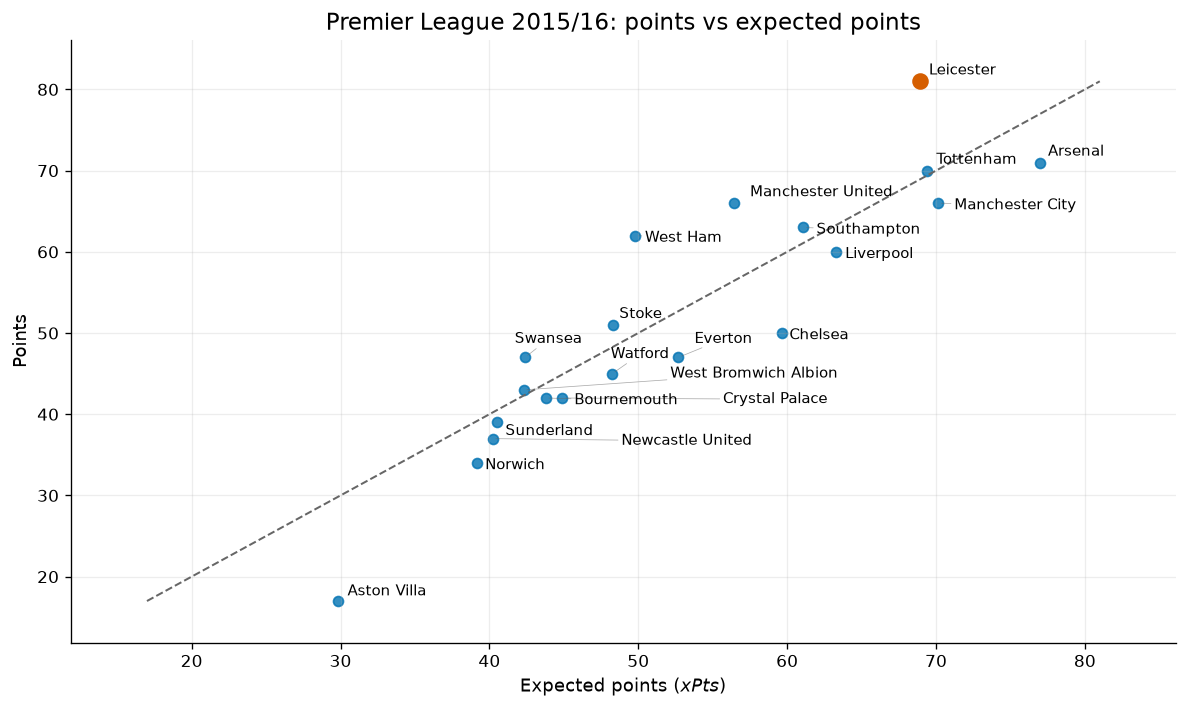

In [10]:
fig, ax = plot_identity_scatter(
    epl_2015,
    x="xpts",
    y="pts",
    highlight=["Leicester"],
    title="Premier League 2015/16: points vs expected points",
    xlabel="Expected points ($xPts$)",
    ylabel="Points",
)
plt.show()

Leicester gained 81 points compared with 68.94 $xPts$, an excess of
12.06 points. West Ham has a similarly large positive difference
(12.20), while Aston Villa is 12.81 points below expectation. The sign
used here is actual points minus expected points; this corrects the
reversed interpretation that results from reading Understat's original
`xpts_diff = xPts - points` column as if positive meant
overperformance.

### 6.2 Goals and expected goals

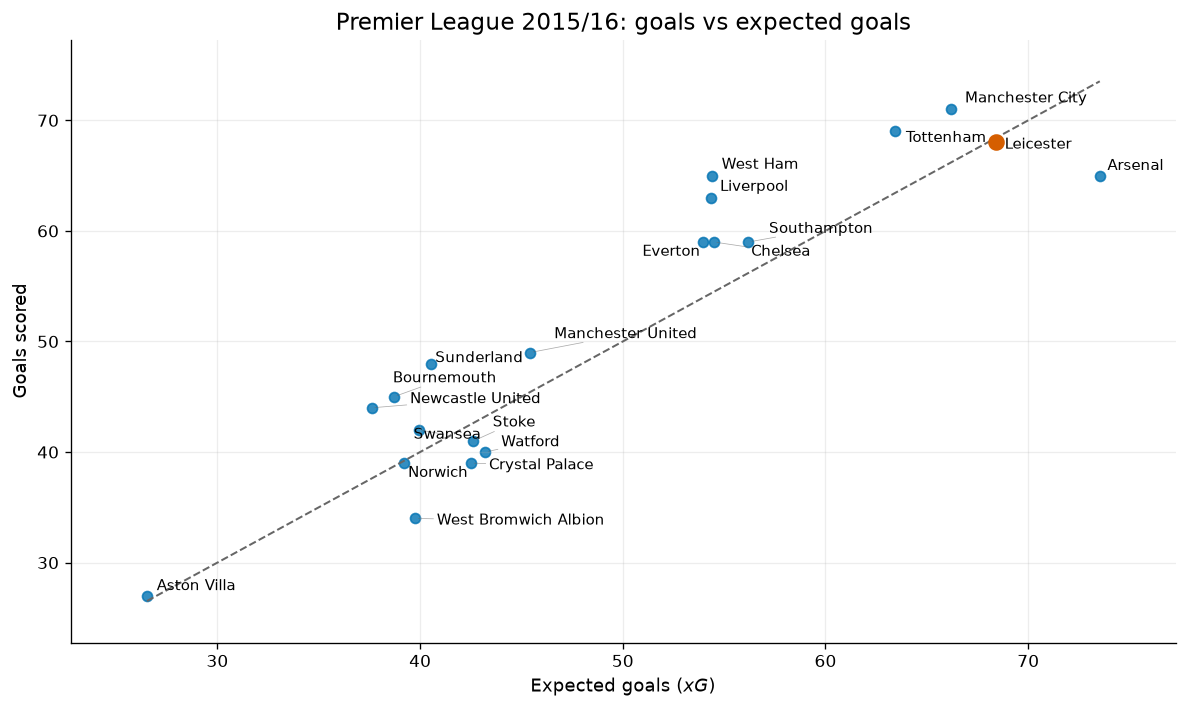

In [11]:
fig, ax = plot_identity_scatter(
    epl_2015,
    x="xg",
    y="scored",
    highlight=["Leicester"],
    title="Premier League 2015/16: goals vs expected goals",
    xlabel="Expected goals ($xG$)",
    ylabel="Goals scored",
)
plt.show()

Leicester scored 68 goals from 68.42 $xG$, almost exactly matching the
quality of its chances (-0.42 goals relative to $xG$). The title was
therefore not driven by exceptional attacking conversion. West Ham and
Liverpool show much larger positive attacking differences, whereas
Arsenal scored 8.53 goals fewer than its $xG$.

### 6.3 Goals conceded and expected goals against

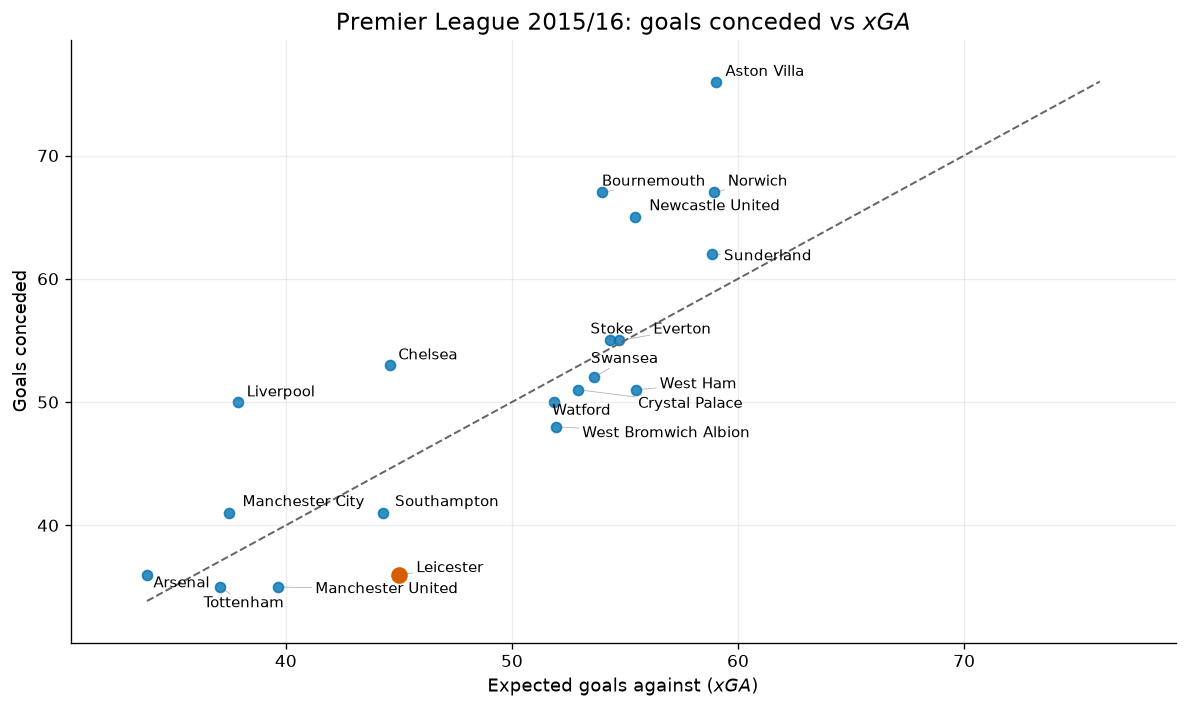

In [12]:
fig, ax = plot_identity_scatter(
    epl_2015,
    x="xga",
    y="missed",
    highlight=["Leicester"],
    title="Premier League 2015/16: goals conceded vs $xGA$",
    xlabel="Expected goals against ($xGA$)",
    ylabel="Goals conceded",
)
plt.show()

Leicester conceded 36 goals from 45.02 $xGA$, or 9.02 fewer than
expected. This defensive difference is much more pronounced than the
attacking difference and is a central part of the case-study
interpretation. It can reflect goalkeeping, shot outcomes, defensive
actions not fully represented by $xGA$, and randomness; the descriptive
comparison alone does not identify their separate contributions.

### 6.4 Pressing profile and DBSCAN

Here, *pressing* means the team's attempt to restrict the opponent's
build-up by applying defensive pressure. `PPDA` is the number of
opponent passes allowed per defensive action in the relevant zones;
lower values therefore indicate more active pressing. `OPPDA` is the
analogous coefficient faced by the team when it has the ball and
describes the pressure applied by its opponents.

DBSCAN is used only as an exploratory grouping tool for the 20 teams.
The two variables are standardized. `min_samples = 3` requires at
least a small three-team neighbourhood, and `eps = 0.73` is selected
after inspecting the third-nearest-neighbour distances and nearby
parameter values. It reproduces the existing three-cluster solution
with two noise points. The sensitivity table is kept in the notebook
because the number of clusters changes in the immediate neighbourhood;
the groups should therefore not be treated as uniquely identified
latent classes.

In [13]:
pressing_features = ["ppda_coef", "oppda_coef"]
dbscan_k_distances = get_dbscan_k_distance_table(
    epl_2015,
    feature_cols=pressing_features,
    min_samples=DBSCAN_MIN_SAMPLES,
    label_col="team",
)
dbscan_sensitivity = summarize_dbscan_sensitivity(
    epl_2015,
    feature_cols=pressing_features,
    eps_values=[0.68, 0.70, 0.73, 0.75, 0.78],
    min_samples=DBSCAN_MIN_SAMPLES,
)

display(dbscan_k_distances.tail(10).round(3))
display(dbscan_sensitivity)

,team,k_distance
10,Bournemouth,0.62
11,Norwich,0.66
12,Stoke,0.72
13,Aston Villa,0.74
14,Swansea,0.74
15,Southampton,0.74
16,Chelsea,0.74
17,Tottenham,0.83
18,Manchester City,0.95
19,Everton,0.99


,eps,n_clusters,n_noise,cluster_sizes
0,0.68,4,3,"3, 4, 5, 5"
1,0.70,4,3,"3, 4, 5, 5"
2,0.73,3,2,"5, 5, 8"
3,0.75,2,2,"5, 13"
4,0.78,2,2,"5, 13"


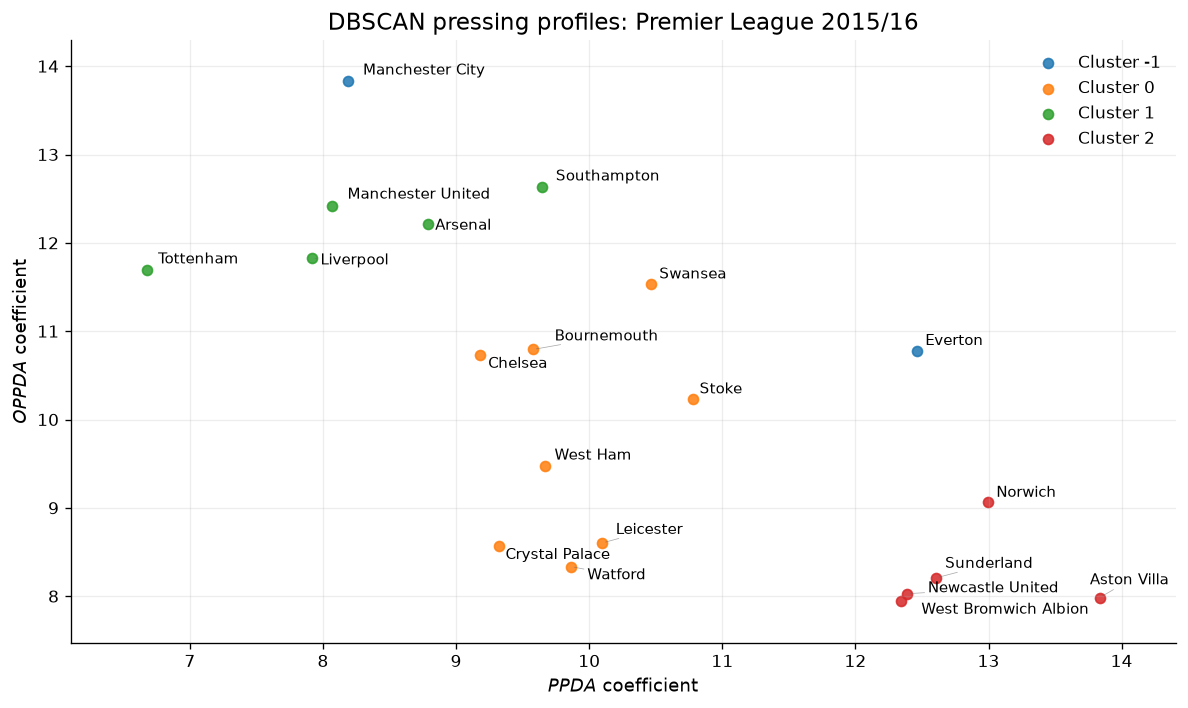

,dbscan_cluster,team
0,-1,Everton
1,-1,Manchester City
2,0,Bournemouth
3,0,Chelsea
4,0,Crystal Palace
5,0,Leicester
6,0,Stoke
7,0,Swansea
8,0,Watford
9,0,West Ham


In [14]:
dbscan_raw = run_dbscan(
    epl_2015.sort_values(["position", "team"]),
    feature_cols=pressing_features,
    eps=DBSCAN_EPS,
    min_samples=DBSCAN_MIN_SAMPLES,
    scale=True,
    label_cols=["position", "team"],
)

# Numeric DBSCAN labels are arbitrary. Anchors keep the labels aligned
# with the existing thesis figure even if implementation details change.
dbscan_pressing = relabel_clusters_by_anchors(
    dbscan_raw,
    cluster_col="dbscan_cluster",
    label_col="team",
    anchor_by_new_label={
        -1: "Manchester City",
        0: "Leicester",
        1: "Arsenal",
        2: "Aston Villa",
    },
).sort_values(["dbscan_cluster", "position", "team"])

expected_pressing_members = {
    -1: ["Everton", "Manchester City"],
    0: [
        "Bournemouth", "Chelsea", "Crystal Palace", "Leicester",
        "Stoke", "Swansea", "Watford", "West Ham",
    ],
    1: [
        "Arsenal", "Liverpool", "Manchester United",
        "Southampton", "Tottenham",
    ],
    2: [
        "Aston Villa", "Newcastle United", "Norwich",
        "Sunderland", "West Bromwich Albion",
    ],
}
observed_pressing_members = {
    int(cluster): sorted(group["team"].tolist())
    for cluster, group in dbscan_pressing.groupby("dbscan_cluster")
}
assert observed_pressing_members == expected_pressing_members

fig, ax = plot_cluster_scatter(
    dbscan_pressing,
    x="ppda_coef",
    y="oppda_coef",
    cluster_col="dbscan_cluster",
    label_col="team",
    title="DBSCAN pressing profiles: Premier League 2015/16",
)
ax.set_xlabel("$PPDA$ coefficient")
ax.set_ylabel("$OPPDA$ coefficient")
plt.show()

display(
    get_cluster_members(
        dbscan_pressing,
        cluster_col="dbscan_cluster",
        label_col="team",
    )
)

Leicester belongs to the eight-team middle cluster (cluster 0).
Cluster 1 contains five teams with lower mean $PPDA$ and higher mean
$OPPDA$, consistent with a more aggressive pressing profile. Cluster 2
contains five teams with high $PPDA$ and low $OPPDA$, consistent with a
more passive profile. Manchester City and Everton are labelled as
noise because they do not meet the density rule for any cluster. The
result places Leicester in a recognisable tactical group rather than
presenting it as a unique pressing outlier.

## 7. Hierarchical clustering of team profiles

The hierarchical analysis is retained with minimal conceptual change.
Six standardized variables describe chance creation, chance
prevention, conversion relative to expectation, points relative to
expectation, pressing, and entries into dangerous areas:

- `xg`;
- `xga`;
- `goals_minus_xg` (positive means goals above xG);
- `points_minus_xpts` (positive means points above xPts);
- `ppda_coef`;
- `deep`.

Changing from Understat's original difference columns to the two
intuitive differences only multiplies those standardized dimensions by
$-1$. Their Euclidean distances, and therefore Ward's grouping, stay
unchanged, while the cluster summaries become much easier to
interpret. The dendrogram is cut into four groups, with the cut shown
explicitly.

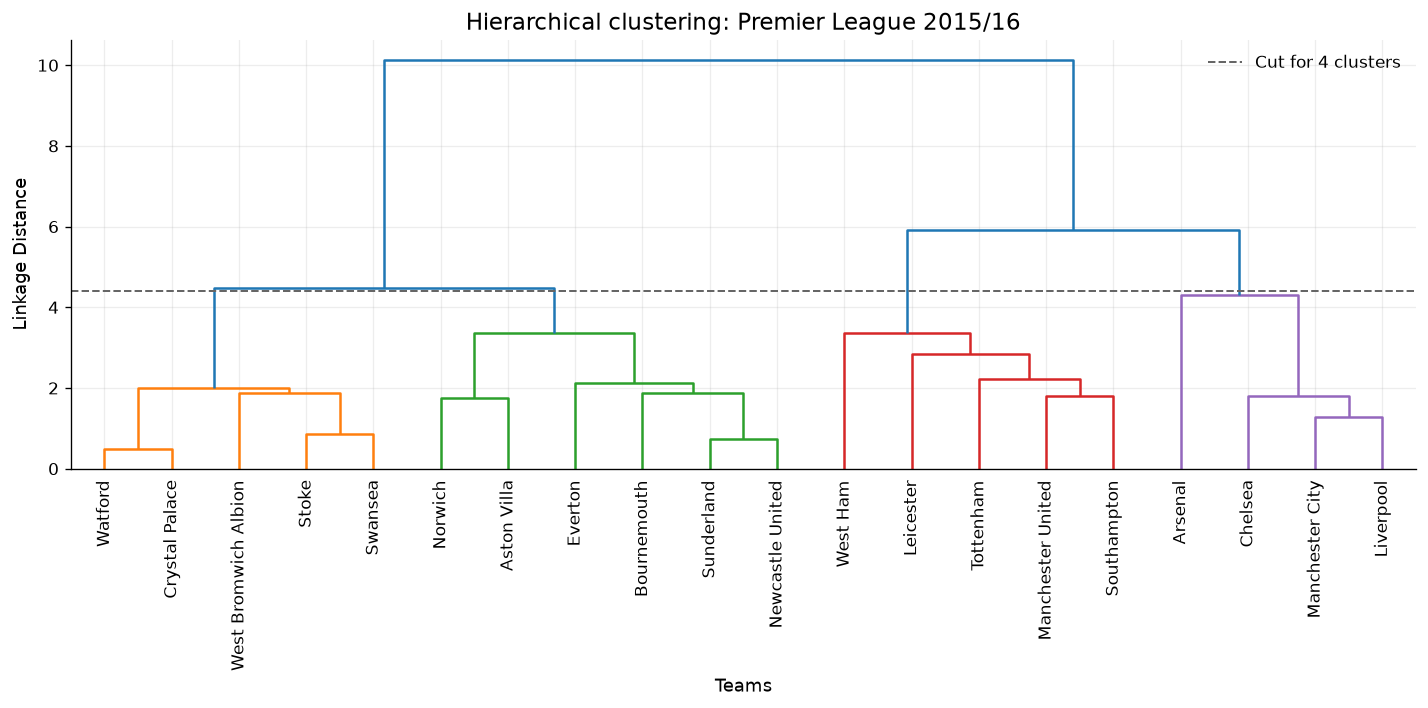

,hier_cluster,team
0,0,Arsenal
1,0,Chelsea
2,0,Liverpool
3,0,Manchester City
4,1,Aston Villa
5,1,Bournemouth
6,1,Everton
7,1,Newcastle United
8,1,Norwich
9,1,Sunderland


,hier_cluster,xg,xga,goals_minus_xg,points_minus_xpts,ppda_coef,deep,n_observations
0,0,62.14,38.46,2.36,-5.76,8.52,393.25,4
1,1,39.42,56.82,4.25,-5.03,12.31,185.83,6
2,2,57.57,44.30,4.43,7.26,8.83,246.40,5
3,3,41.61,52.94,-2.41,0.37,10.55,177.80,5


Dendrogram cut height: 4.391


In [15]:
hierarchical_features = [
    "xg", "xga", "goals_minus_xg", "points_minus_xpts",
    "ppda_coef", "deep",
]
hierarchical_raw, linkage_matrix = run_hierarchical_clustering(
    epl_2015.sort_values(["position", "team"]),
    feature_cols=hierarchical_features,
    n_clusters=N_HIERARCHICAL_CLUSTERS,
    method="ward",
    metric="euclidean",
    scale=True,
    label_cols=["position", "team"],
)
hierarchical_teams = relabel_clusters_by_anchors(
    hierarchical_raw,
    cluster_col="hier_cluster",
    label_col="team",
    anchor_by_new_label={
        0: "Arsenal",
        1: "Aston Villa",
        2: "Leicester",
        3: "Crystal Palace",
    },
).sort_values(["hier_cluster", "position", "team"])

expected_hierarchical_members = {
    0: ["Arsenal", "Chelsea", "Liverpool", "Manchester City"],
    1: [
        "Aston Villa", "Bournemouth", "Everton",
        "Newcastle United", "Norwich", "Sunderland",
    ],
    2: [
        "Leicester", "Manchester United", "Southampton",
        "Tottenham", "West Ham",
    ],
    3: [
        "Crystal Palace", "Stoke", "Swansea", "Watford",
        "West Bromwich Albion",
    ],
}
observed_hierarchical_members = {
    int(cluster): sorted(group["team"].tolist())
    for cluster, group in hierarchical_teams.groupby("hier_cluster")
}
assert observed_hierarchical_members == expected_hierarchical_members

hierarchical_summary = summarize_clusters(
    hierarchical_teams,
    cluster_col="hier_cluster",
    feature_cols=hierarchical_features,
    count_label="team",
)

fig, ax, cut_height = plot_dendrogram(
    linkage_matrix,
    labels=hierarchical_raw["team"].tolist(),
    title="Hierarchical clustering: Premier League 2015/16",
    n_clusters=N_HIERARCHICAL_CLUSTERS,
)
plt.show()

display(get_cluster_members(hierarchical_teams, "hier_cluster", "team"))
display(hierarchical_summary.round(3))
print(f"Dendrogram cut height: {cut_height:.3f}")

Cluster 0 contains Arsenal, Chelsea, Liverpool, and Manchester City and
represents the structurally dominant teams with high $xG$ and low
$xGA$, although their average points total is below $xPts$. Cluster 1
contains the weakest broad profile: low $xG$, high $xGA$, higher
$PPDA$, and points below $xPts$. Cluster 2 contains Leicester together
with Manchester
United, Southampton, Tottenham, and West Ham; it combines relatively
strong expected performance with the largest positive points-minus-xPts
value. Cluster 3 is a more balanced lower-output group whose points are
close to expectation.

Leicester's membership in cluster 2 supports the case-study story: its
season was not identical to the most territorially dominant teams, but
it combined a competitive underlying profile with particularly strong
realised points and defensive outcomes.

## 8. Freeze analytical outputs for the Czech thesis notebook

The Czech notebook does not rerun clustering. It reads these neutral
CSV files, localises labels, and exports the selected PDF figures and
CSV tables. This separation guarantees that language and styling
changes cannot alter cluster membership.

In [16]:
cache_outputs = {
    "league_per_match.csv": league_per_match,
    "season_completeness.csv": completeness,
    "rolling_match_top5_ma490.csv": (
        rolling_match_top5_ma490
    ),
    "rolling_match_la_liga_ma100.csv": (
        rolling_match_la_liga_ma100
    ),
    "long_term_team_ratios.csv": team_ratios,
    "top_offensive.csv": top_offensive,
    "top_defensive.csv": top_defensive,
    "epl_2015.csv": epl_2015,
    "dbscan_k_distances.csv": dbscan_k_distances,
    "dbscan_sensitivity.csv": dbscan_sensitivity,
    "dbscan_pressing_assignments.csv": dbscan_pressing,
    "hierarchical_assignments.csv": hierarchical_teams,
    "hierarchical_summary.csv": hierarchical_summary,
    "hierarchical_linkage.csv": pd.DataFrame(
        linkage_matrix,
        columns=["left", "right", "distance", "count"],
    ),
    "hierarchical_labels.csv": hierarchical_raw[
        ["position", "team"]
    ].reset_index(drop=True),
}

for filename, frame in cache_outputs.items():
    frame.to_csv(CACHE_DIR / filename, index=False)

metadata = {
    "rolling_continuous_across_seasons": True,
    "rolling_complete_seasons_only": True,
    "rolling_level": "physical_match",
    "rolling_top5_window": MATCH_ROLLING_WINDOW_TOP5,
    "rolling_la_liga_window": MATCH_ROLLING_WINDOW_LA_LIGA,
    "rolling_monthly_aggregation": False,
    "selected_time_series_league": SELECTED_TIME_SERIES_LEAGUE,
    "dbscan_eps": DBSCAN_EPS,
    "dbscan_min_samples": DBSCAN_MIN_SAMPLES,
    "hierarchical_n_clusters": N_HIERARCHICAL_CLUSTERS,
    "stable_team_count": stable_team_count,
    "season_data_rows": len(season_data),
    "match_data_rows": len(match_data),
}
(CACHE_DIR / "analysis_metadata.json").write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

exported = pd.DataFrame(
    {
        "file": sorted([*cache_outputs, "analysis_metadata.json"]),
    }
)
display(exported)

,file
0,analysis_metadata.json
1,dbscan_k_distances.csv
2,dbscan_pressing_assignments.csv
3,dbscan_sensitivity.csv
4,epl_2015.csv
5,hierarchical_assignments.csv
6,hierarchical_labels.csv
7,hierarchical_linkage.csv
8,hierarchical_summary.csv
9,league_per_match.csv
